<center>
    <p>115 Theoretical Neuroscience II</p>
    <h1></h1>
    <h1>Lecture 10:</h1>
    <h1>Temporal Difference Learning</h1>
    <p>----</p>
    <p>Prof. Jochen Braun Ph.D.</p>
    <p>Institute of Biology</p>
    <p>Otto-von-Guericke University Magdeburg</p>
    <p>----</p>
    <p>Textbook:</p>
    <p>Peter Dayan & Larry Abbott (2001) Theoretical Neuroscience, MIT Press.</p>
    <p> Sutton & Barto (2018)  Reinforcement Learning, Chapters~3-7, MIT Press. </p>
</center>

In [ ]:
from IPython.display import display, Math

# Inject custom MathJax configuration for additional packages
custom_latex = r"""
\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{eufrak}
"""

# **Abstract:**

Extend reinforcement from rewards to changing expectations ('temporal difference'), learning to anticipate **delayed** rewards and to actively procure them ($\to$ next lecture).


**TDL for episodic tasks:** Learn to associate events ${\bf u}$ with delayed reward expectations ${\bf w}(\tau)$.  Focus on total reward (future *and* present), not just present reward.  TDL explains 'trace' and 'secondary' conditioning.  Raised and lowered expectations (promises \& threats) become equivalent to rewards and punishments.

**TDL for continuous tasks:** Illustrate generalized framework with 'gridworld', where 'agent' seeks exit.  Learn to associate expected total future reward $V_\pi(s)$ with states $s$ by accumulating value function (VF).  We compute theoretical VF and compare VF obtained by TDL. For active agent, VF depends on action policy $\pi(a)$.  Learning this action policy is subject of next lecture.

<br>

# **Overview:**

**1 Rescorla-Wagner recap**

**2 TD learning for episodic tasks**

**3 Trace conditioning**

**4 Secondary conditioning**

**5 General formulation of reinforcement learning**

**6 Gridworld**

**7 TD learning for continuous tasks**

<br>

**Credits:**

D&A, Chapter 9, Conditioning and reinforcement

# **1. Rescorla-Wagner recap**

In the last lecture, we modeled reinforcement learning in terms of **external** stimuli and rewards ...

$$
\mathrm{Stimuli} \qquad\qquad {\bf u}(t) = \left\{ \begin{array}{cc} 1 & \mathrm{if \,\, present}\\ 0 & \mathrm{if \,\, absent} \end{array}\right.
\\
\mathrm{Rewards} \qquad\qquad r(t)\qquad\qquad\qquad
$$

... and in terms of **internal** weights (reward expectations) associated with each stimulus

$$
\mathrm{Conditional \,\, expectation} \qquad\qquad {\bf w}(t)\qquad\qquad\qquad\qquad
\\
\mathrm{Total \,\, expected \,\, reward} \qquad\qquad v = {\bf w}(t) \cdot {\bf u}(t) \qquad\qquad
$$


The experience gained by trial and error was captured by the **Rescorla-Wagner rule**:

$$
{\bf w} \rightarrow {\bf w} + \epsilon \, \delta \, {\bf u}, \qquad\qquad \delta = r - v
$$

where  $\delta$ is the **prediction error** (surprise) and $\epsilon$ is a **learning rate**.  Over time, weights converge to the conditional expected reward:

$$
w_k \quad \rightarrow \quad \langle r | u_k \rangle
$$


Intuitively, a *positive* surprise $\delta$ attaches the *merit* to all stimuli present,  *increasing* their weights.


A *negative* surprise $\delta$ attaches the  *blame* to all stimuli present, *decreasing* their weights.



<br>

While the RW accounts for reinforcement learning when stimuli and rewards are in close temporal proximity  ...

<br>

- Pavlovian conditioning.

- Extinction

- Partial conditioning

- Blocking

- Overshadowing

<br>

... it fails to account for the ability of animals to anticipate delayed rewards:

<br>

- Trace conditioning

- Secondary conditioning

# **2. TD learning for episodic tasks**

<br>

We now formulate a scheme for learning to expect delayed rewards ('temporal-difference learning' or 'TDL').  The crucial modifications will be:

<br>

- Learn to predict **total reward** (present and future), not just present reward.  Total reward is **time-integrated** reinforcement, not **instantaneous** reinforcement.


- Form prediction error $\delta$ from the **temporal difference** of this expectation of reinforcement.

- Rising expectations (promises) become equivalent to rewards, falling expectations (threats) equivalent to punishments.

- To associate observed stimuli $\bf u$ with  *delayed* rewards $\ldots$


- $\ldots$ by learning weights $\bf w(\tau) $ that are functions of delay $\tau$.


# Episodic task: coarse $t$ vs. fine $\tau$

<br>

From trial to trial, 'coarse' time $t$ increases in steps of $\Delta t$.  Within each trial, 'fine' time $\tau$ grows in steps of $\Delta \tau$, up to the trial duration $\tau_{max}$.   The 'foresight' of our scheme will end at $\tau_{max}$.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Episodic_task.png" width="600">



# ctd

<br>

Both *external* and *internal* state variables depend on within-trial time $\tau$ and will be updated between trials $i$

<br>

$$
\mathrm{Stimuli} \qquad\qquad\qquad {\bf u}_i(\tau),\qquad\quad\qquad \tau \, \mathrm{time} \quad\qquad\quad
$$

<br>

$$
\mathrm{Rewards} \qquad\qquad\qquad r_i(\tau)\qquad\quad\qquad\quad\qquad\qquad\qquad
$$

<br>

$$
\mathrm{Conditional \,\, expect.} \qquad\qquad\quad {\bf w}_i(\Delta\tau),\qquad\qquad\Delta \tau \, \mathrm{delay} \qquad\quad
$$

<br>

$$
\mathrm{Total \,\, expect.} \qquad\qquad v_i(\tau) = \sum^{\tau}_{\Delta\tau=0} \, {\bf w}_i(\Delta\tau) \cdot {\bf u}_i(\tau-\Delta\tau)
$$

<br>

where $i$ is the trial index.  $v_i$ sums up the total expectations (present and future) raised by stimuli from the past.

# TD learning rule

<br>

Define $v_i(\tau)$ as *total expected reward*, from $\tau$ to $\tau_{max}$:

<br>

$$
v_i(\tau)  =  \left\langle\sum_{\tau'=\tau}^{\tau_{max}} \, r(t,\tau')\right\rangle
$$

<br>

Our goal is to compute this from *past* events and *current* rewards in the usual manner:

<br>

$$
\mathrm{Total \, expectation} \qquad\qquad\qquad v_i(\tau) = \sum_{\Delta\tau=0}^{\tau} \, {\bf w}_i(\Delta\tau) \cdot {\bf u}_i(\tau-\Delta\tau)
$$

<br>

$$
\mathrm{Specific \, expecations} \qquad\qquad\qquad {\bf w}_{i+1}(\tau) = {\bf w}_i(\tau) + \epsilon \, \delta(\tau) \, {\bf u}_i(\tau)
\qquad\qquad\qquad
$$

<br>

$$
\mathrm{Prediction \, error} \qquad\qquad\qquad\qquad \delta(\tau) = -v_i(\tau) + \sum_{\tau'=\tau}^{\tau_{max}} \, r_i(\tau')\qquad\qquad
$$

# Circular logic problem!

<br>

At time $\tau$, we know only present $r_i(\tau)$, not future  $r_i(\tau'>\tau)$.

<br>

$$
\delta(\tau) = -v_i(\tau) + r_i(\tau) + \sum_{\tau'>\tau} \, r_i(\tau')
$$

<br>

We cannot compute this directly!  Instead, we must 'bootstrap' and assume

<br>

$$
 \sum_{\tau'>\tau} \, r_i(\tau') \approx v_i(\tau + \Delta \tau)
$$

<br>

This assumption is equivalent to basing prediction error on 'changing expectations'

<br>

$$\begin{eqnarray}
\delta(\tau) &\approx & -v_i(\tau) + r_i(\tau) + v_i(\tau+\Delta \tau) \quad = \quad r_i(\tau) + \underbrace{\Delta v_i(\tau)}_{\mathrm{changing \\ expectations}}
\end{eqnarray}$$

# ctd

<br>

The TD learning scheme thus involves *summing* delayed expectations ${\bf w}(\tau)$

<br>

$$\begin{eqnarray}
v_i(\tau) &=& \sum_{\Delta\tau=0}^{\tau} \, {\bf w}_i(\Delta\tau) \cdot {\bf u}_i(\tau-\Delta\tau)'
\end{eqnarray}$$

<br>

*updating* expectations

<br>

$$\begin{eqnarray}
{\bf w}_i(\Delta t,\tau) &=& {\bf w}_i(\tau) + \epsilon \, \delta(\tau) \, {\bf u}_i(\tau)'
\end{eqnarray}$$

<br>

and the *temporal difference* prediction error

<br>

$$\begin{eqnarray}
\delta(\tau) &=& r_i(\tau) + \Delta v_i(\tau), \qquad\qquad \Delta v_i(\tau) = v_i(\tau+\Delta \tau) - v_i(\tau).
\end{eqnarray}$$

<br>

Positive (negative) prediction errors at time $\tau$ arise either from actual rewards (punishments) $r_i(\tau)$ or, equivalently, from rising (lowering) expectations $\Delta v_i(\tau)$ !


# Points to note

TD learning for episodic tasks involves:

<br>

- Redefining the expected reward $v_i(\tau)$ as the *total expectyed reward* from $\tau$ to $\tau_{max}$.

- Weights ${\bf w}(\Delta\tau)$ predict when and how much expectations change!

- Computing the prediction error $\delta(\tau)$ as the sum of any reinforcement $r_i(\tau)$ and of changing expectations $\Delta v_i(\tau)$.

- Thus, in TD learning, rising hopes are equivalent to rewards, and falling hopes are equivalent to punishments.

<br>

- Psychologically plausible: viscerally/neuromodulatory *motivating* or *demotivating* effect of **promises** or **threats**!



# **3. Trace conditioning**

We apply TD learning to ''trace conditioning'', or learning to anticipate rewards that are delayed relative to the associated stimulus.

<br>

For simplicity, we consider identical trials in which stimuli and rewards always occur at the same within-trial time $\tau$.

<br>

Note that, as long as the delay $\Delta \tau$ between stimulus and reward remains the same, we would obtain equivalent results for variable within-trial times.

# 32 trials trace conditioning


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC_Stimulus_reward.png" width="400">

Every trial has a stimulus $u$ (blue) at $\tau=4$ and a reward $r$ (orange) at $\tau=12$.

# Prediction error $\delta(\tau)$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC_Prediction_error.png" width="400">

Prediction $\delta(\tau)$ is reward $r(\tau)$ plus changed expectation $\Delta v(\tau)$.


Every $\delta(\tau)$ increments delayed expectation $w(\tau-\tau')$ for earlier stimuli $u(\tau')$.  This gradually transfers prediction error from $\tau=12$ to $\tau=4$.

# Total expected reward $v(\tau)$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC_Total_expectation.png" width="400">


$v(\tau)$ is obtained by summing up delayed expectation weights $w(\tau)$ for earlier stimuli $u(\tau')$.


Total expectation gradually rises between $\tau=4$ and $\tau=12$.


# Delayed weights $w(\Delta \tau)$


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC_Delayed_weights.png" width="400">


Delayed weights are incremented for earlier stimuli $u(\tau')$, whenever there is a prediction error $\delta(\tau)$.


Weights gradually rise between $\Delta \tau=0$ and $\Delta \tau=8$.

# 80 trials trace conditioning

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC80_Stimulus_reward.png" width="400">


Every trial comprises a stimulus at $\tau=4$ and a reward at $\tau=12$.

# Prediction error $\delta(\tau)$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC80_Prediction_error.png" width="400">

The prediction error is transferred from $\tau=12$ to $\tau=4$.

Total reward expectation $v(\tau)$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC80_Total_expectation.png" width="400">


Total future reward rises between $\tau=4$ and $\tau=12$.

Delayed weights $w(\Delta \tau)$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TC80_Delayed_weights.png" width="400">

Weights rise between $\Delta \tau=0$ and $\Delta \tau=8$.

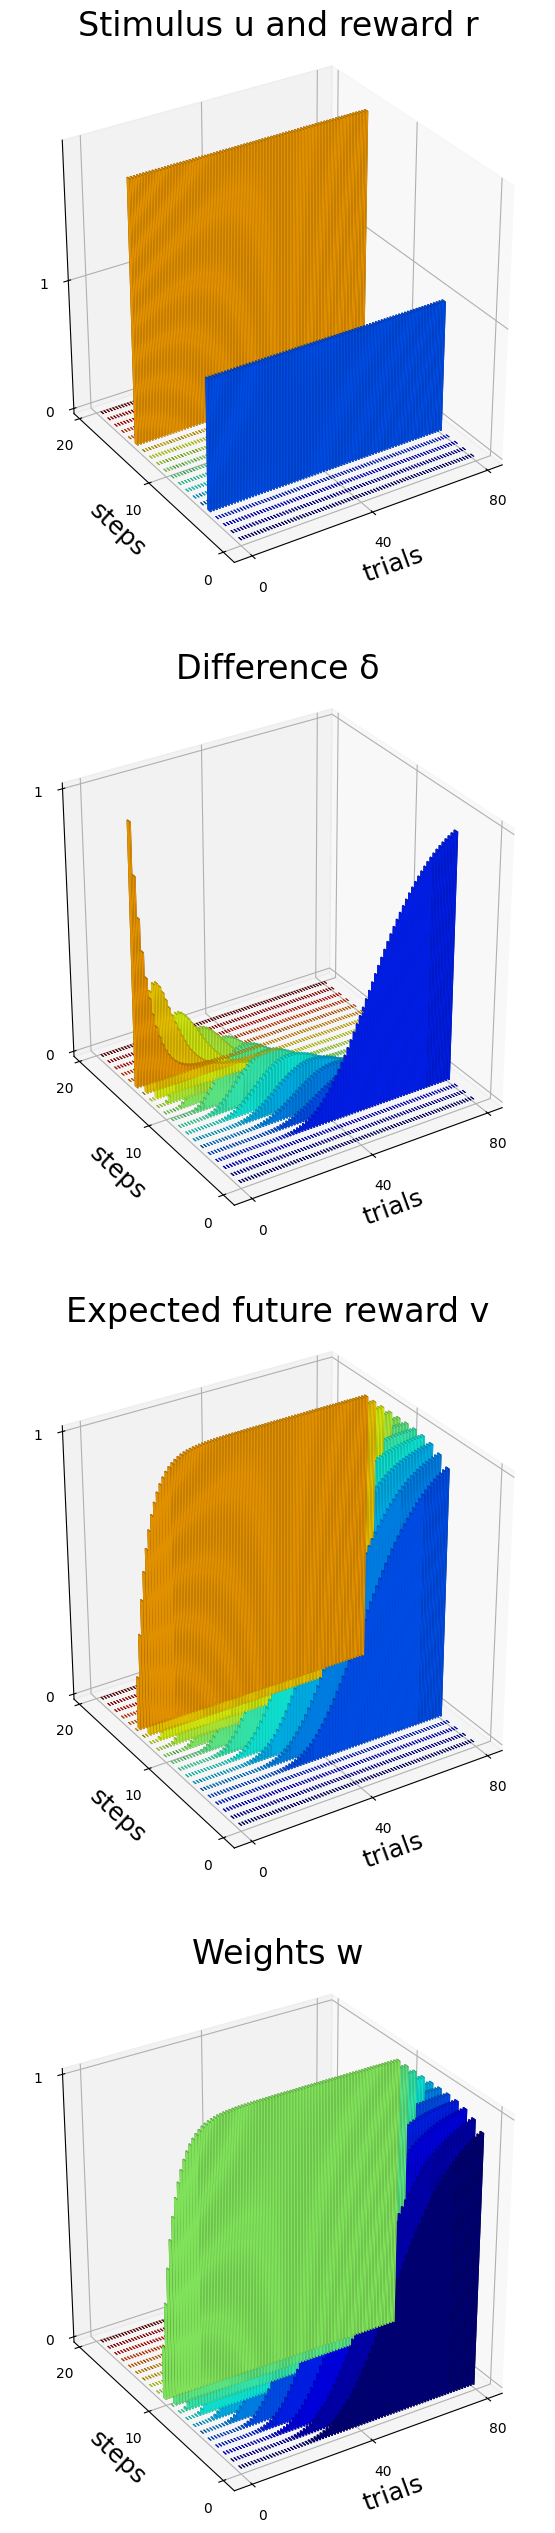

In [ ]:
# @title Trace conditioning {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Visualization functions
def plot_3d_bar(ax, data, Nstep, Ntrial, title, zlim=(0, 1)):

    # size of bars
    width = depth = 0.4

    # Get the jet colormap
    cmap = plt.get_cmap('jet')

    # Generate 80 evenly spaced values between 0 and 1
    colors = [cmap(i / (Nstep - 1)) for i in range(Nstep)]
    colors = np.array(colors)

    x, y = np.meshgrid(range(Ntrial), range(Nstep),indexing='ij')

    data = np.reshape(data,(Ntrial,Nstep))

    #x = x.flatten()
    #y = y.flatten()
    z = np.zeros_like(x, dtype=float)
    dx = dy = 0.4
    dz = np.reshape(data,(Ntrial,Nstep))
    #dz = data.flatten()

    #for i in range(Nstep-1,-1,-1):
    for i in range( Nstep ):
        color = np.squeeze( colors[i,:] )
        ax.bar3d(x[:,i], y[:,i], z[:,i], dx, dy, dz[:,i], color=color, shade=True)

    #for i in range(int(Nstep/3),int(2*Nstep/3), 1):
    #    color = np.squeeze( colors[i,:] )
    #    ax.bar3d(x[:,i], y[:,i], z[:,i], dx, dy, dz[:,i], color=color, shade=True)

    # for i in range(0,int(Nstep/3),1):
    #    color = np.squeeze( colors[i,:] )
    #    ax.bar3d(x[:,i], y[:,i], z[:,i], dx, dy, dz[:,i], color=color, shade=True)

    ax.set_xticks([0, Ntrial // 2, Ntrial])
    ax.set_yticks([0, Nstep // 2, Nstep])
    ax.set_zticks([0, 1])
    ax.set_xlabel('trials', fontsize=18)
    ax.set_ylabel('steps', fontsize=18)
    ax.set_title(title, fontsize=24)
    ax.view_init(azim=-122.5, elev=30)
    ax.set_box_aspect([1, 1, 1])


# Parameters
Nstep = 20
Ntrial = 80
Nstim = 1
epsilon = 0.2

# Initialize arrays
u = np.zeros((Nstim, Ntrial, Nstep))  # stimulus(in, it, is)
r = np.zeros((Ntrial, Nstep))        # actual reward (it, is)
v = np.zeros((Ntrial, Nstep))        # expected reward (it, is)
delta = np.zeros((Ntrial, Nstep))    # difference actual and expected (it, is)
w = np.zeros((Nstim, Ntrial, Nstep)) # weight(in, it, tau)

# Set stimulus appearance time at step 5 (index 4 in 0-based indexing)
u[0, :, 4] = np.ones(Ntrial)

# Set reward delivery time at step 15 (index 14 in 0-based indexing)
r[:, 14] = np.ones(Ntrial)

# Iterate over trials
for it in range(Ntrial):
    # Compute new predictions based on weights and stimuli seen so far
    for is_ in range(1, Nstep):
        for tau in range(is_):
            v[it, is_] += w[0, it, tau] * u[0, it, is_ - tau]

    # Temporal difference rule: compare actual reward with difference in expectation
    v_shifted = np.concatenate((v[it, 1:], [0]))
    delta[it, :] = r[it, :] + v_shifted - v[it, :]

    # Loop over steps, looking for stimuli
    for is_ in range(Nstep):
        if u[0, it, is_] == 1:
            # Loop over maximal range of tau, given stimulus step
            for tau in range(Nstep - is_):
                w[0, it, tau] += epsilon * delta[it, is_ + tau]

    # Carry over weights to next trial
    if it < Ntrial - 1:
        w[0, it + 1, :] = w[0, it, :]


# Visualization, make a figure
fig = plt.figure(figsize=(8, 32))

# choose fontsize
fs = 14
fs2 = 18

X, Y = np.meshgrid(range(Nstep), range(Ntrial))
Z = u[0, :, :] + 2 * r

bottom = np.zeros_like(Z)

# Visualization: Plotting stimulus u and reward r
ax1 = fig.add_subplot(411, projection='3d')
plot_3d_bar(ax1, Z, Nstep, Ntrial, 'Stimulus u and reward r', zlim=(0, 1))

# Visualization: Plotting delta
Z = delta

ax2 = fig.add_subplot(412, projection='3d')
plot_3d_bar(ax2, Z, Nstep, Ntrial, 'Difference δ', zlim=(0, 1))

# Visualization: Plotting expected reward v
Z = v

ax3 = fig.add_subplot(413, projection='3d')
plot_3d_bar(ax3, Z, Nstep, Ntrial, 'Expected future reward v', zlim=(0, 1))

# Visualization: Plotting weights w
Z = w[0, :, :]

ax4 = fig.add_subplot(414, projection='3d')
plot_3d_bar(ax4, Z, Nstep, Ntrial, 'Weights w', zlim=(0, 1))

plt.show()

# Points to note:

<br>

Trace conditioning involves:

<br>

- Rewards increase delayed weights, creating rising expectation next time round.

- Rising expectation increase less delayed weights.

- Repeats lead iteratively to an increase in immediate weights.
- Eventually, prediction error shifts from reward to predictive stimulus.

<br>

- Consistent with experimental observations on dopamine neurons!


# 4. Secondary conditioning

<br>

Secondary conditioning involves associating one stimulus with a reward, followed by associating a second stimulus with the first stimulus (but without the reward!). In animals and humans, the second stimulus evokes an expectation of reward (with which it has never been paired).   

<br>

Thus, rewards are used to condition promises (first stimuli), which in turn condition promises of promises (second stimuli).

<br>

Note that this works only as long as there are not too many trials without reward (so that not all expectations are extinguished).

# Trace and secondary conditioning (40 trials each)

<br>

**First stimuli** $u_1$ (green), **second stimuli** $u_2$ (blue) and **rewards** $r$ (orange):

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_SC_Stimuli_reward.jpg" width="400">


$u_1$ at $\tau=8$, $u_2$ at $\tau=4$, $r$ at $\tau=12$.


# Prediction error $\delta(\tau)$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_SC_Prediction_error.jpg" width="400">

$\delta(\tau)$ transfers from $\tau=12$ to $\tau=8$ and then from $\tau=8$ to $\tau=4$.


# Delayed expectation $w(\Delta \tau)$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_SC_Delayed_weights.jpg" width="400">

The weights of the second stimulus are positive for $0\leq \Delta \tau \leq 3$ and negative for $4 \leq \Delta \tau \leq 8$.

TD learning explains secondary conditioning because:

<br>

- The first stimulus evokes a rising expectation $\Delta v$ lasting until the time of the reward.

<br>

- In terms of the prediction error $\delta = r + \Delta v$, this rising expectation is equivalent to an actual reward.

<br>

- If a second stimulus predicts this positive surprise, the second stimulus also also evokes a rising expectation lasting until the time of the first stimulus.

<br>

- Thereafter, the second stimulus evokes a falling expectation (due to the subsequent failure of reward).

# Points to note

Main points of TD learning:

<br>

- From events $u(\tau)$, a future time course $w(\Delta\tau)$ is learned.

<br>

- It predicts total reward expectation, from $\tau+\Delta\tau$ onwards.  

<br>

- Rising reward expectations also act as rewards.

<br>

- Prediction error transferred from reward $\rightarrow$ primary predictor $\rightarrow$ secondary predictor.

<br>

- Endows agent with foresight about delayed rewards.

<br>

- But there is a price to pay!

<br>

This seems psychologically plausible in that it explains our susceptibility to promises \& threats!


delta shape: (80, 16)
u[0,:,:] shape: (80, 16)
r shape: (80, 16)


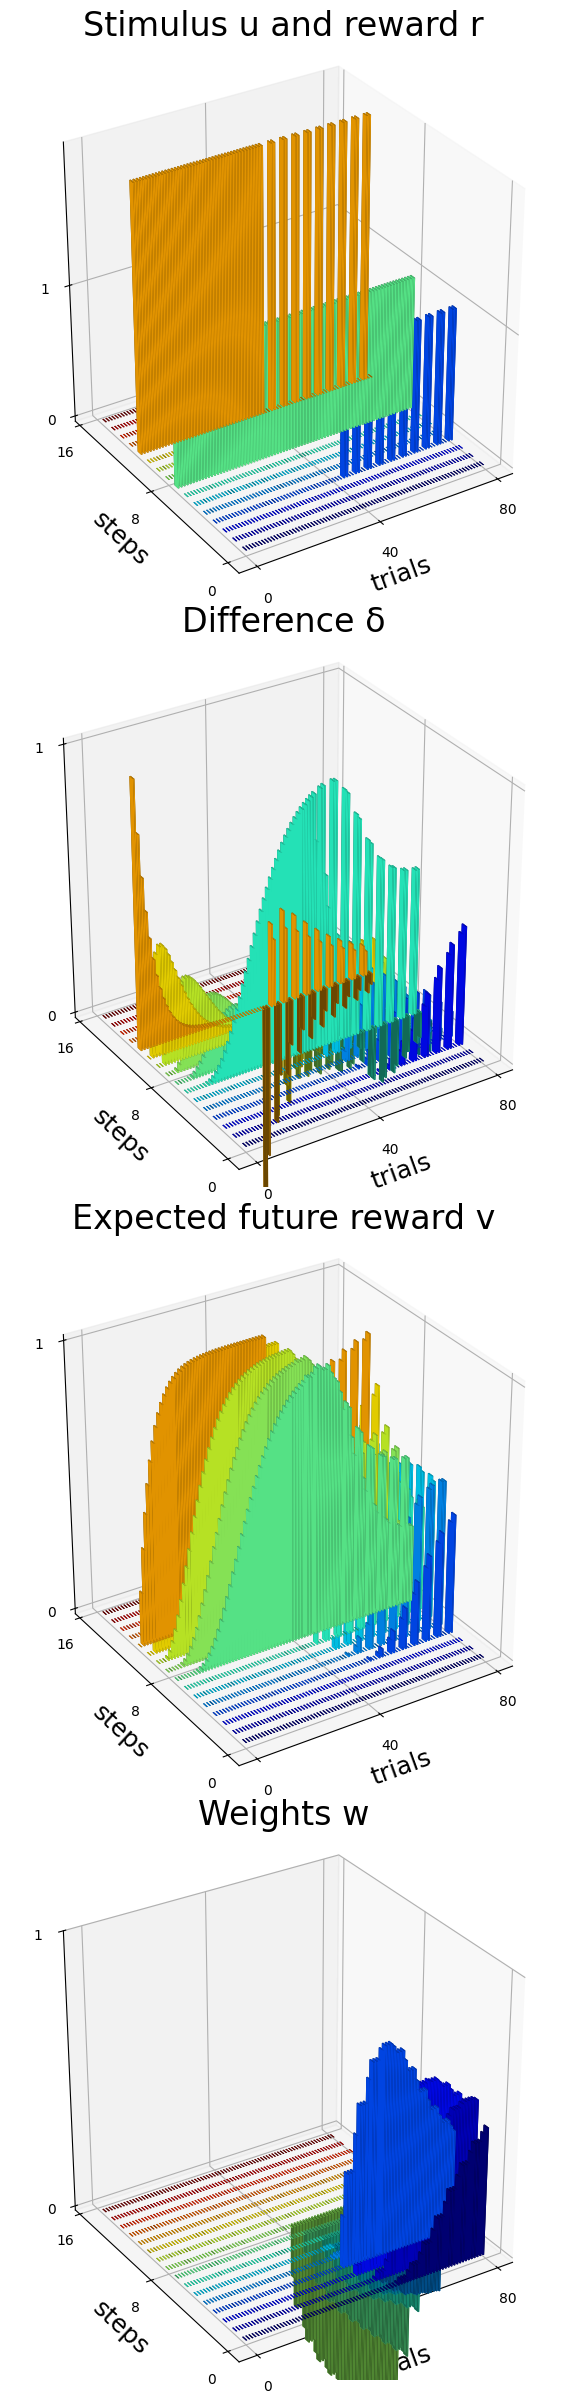

In [ ]:
# @title Secondary conditioning {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
Nstep = 16
Ntrial = 80
Nstim = 2
epsilon = 0.2

# Initialize arrays
u = np.zeros((Nstim, Ntrial, Nstep))  # stimulus(in, it, is)
r = np.zeros((Ntrial, Nstep))        # actual reward (it, is)
v = np.zeros((Ntrial, Nstep))        # expected reward (it, is)
delta = np.zeros((Ntrial, Nstep))    # difference actual and expected (it, is)
w = np.zeros((Nstim, Ntrial, Nstep)) # weight(in, it, tau)

# Set the first stimulus appearance time at step 8 (index 7 in 0-based indexing)
u[0, :, 7] = np.ones(Ntrial)

# Set the reward delivery time at step 12 (index 11)
r[:, 11] = np.ones(Ntrial)

# Compute indices for second stimulus
xx = Ntrial // 2 + np.where(np.mod(np.arange(Ntrial // 2), 4) > 1)[0]

# Set the second stimulus appearance time at step 4 (index 3)
u[1, xx, 3] = np.ones(len(xx))

# Null the reward in the presence of the second stimulus
r[xx, 11] = np.zeros(len(xx))

# Iterate over trials
for it in range(Ntrial):
    # Compute new predictions based on weights and stimuli seen so far
    for istep in range(1, Nstep):
        for tau in range(istep):
            v[it, istep] += (w[0, it, tau] * u[0, it, istep - tau] +
                            w[1, it, tau] * u[1, it, istep - tau])

    # Temporal difference rule
    v_shifted = np.concatenate([v[it, 1:], [0]])
    delta[it, :] = r[it, :] + v_shifted - v[it, :]

    # Loop over steps, looking for stimuli
    for istep in range(Nstep):
        if u[0, it, istep] == 1:
            for tau in range(Nstep - istep):
                w[0, it, tau] += epsilon * delta[it, istep + tau]

        if u[1, it, istep] == 1:
            for tau in range(Nstep - istep):
                w[1, it, tau] += epsilon * delta[it, istep + tau]

    # Carry over weights to next timestep
    if it < Ntrial - 1:
        w[0, it + 1, :] = w[0, it, :]
        w[1, it + 1, :] = w[1, it, :]

# Print array shapes for verification
print("delta shape:", delta.shape)
print("u[0,:,:] shape:", u[0, :, :].shape)
print("r shape:", r.shape)




# make figure
fig = plt.figure(figsize=(6, 24))

# Plot 1: Stimulus u and reward r
ax1 = fig.add_subplot(411, projection='3d')
A = u[0, :, :] + u[1, :, :] + 2 * r
plot_3d_bar(ax1, A, Nstep, Ntrial, 'Stimulus u and reward r', zlim=(0, 2))

# Plot 2: Difference delta
ax2 = fig.add_subplot(412, projection='3d')
plot_3d_bar(ax2, delta, Nstep, Ntrial, 'Difference δ', zlim=(0, 2))

# Plot 3: Expected future reward v
ax3 = fig.add_subplot(413, projection='3d')
plot_3d_bar(ax3, v, Nstep, Ntrial, 'Expected future reward v', zlim=(0, 2))

# Plot 4: Weights w for second stimulus
ax4 = fig.add_subplot(414, projection='3d')
plot_3d_bar(ax4, w[1, :, :], Nstep, Ntrial, 'Weights w', zlim=(0, 2))


plt.tight_layout()

plt.show()


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10-DA-Fig-9-2.jpg" width="800">

# **5. General framework of reinforcement learning**

<br>

Theories of reinforcement learning have developed a number concepts that apply also to biological learning.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Agent_environment.png" width="500">

<br>

At time $t$, an agent in an environment experiences certain states $s(t)$ and reinforcements $r(t)$ and may respond with certain actions $a(t)$.

<br>

As a result, state and reinforcement may change to $s(t+\Delta t)$ and $r(t+\Delta t)$.

# Episodic and continuous tasks

''Total expected reward'' is the reward that we expect the receive the long run (present and future). This definition for **episodic** tasks must be modified for **continuous** tasks:

<br>

**Episodic:** sum until episode ends at $\tau_{max}$

$$
R_\tau = r_{\tau} + r_{\tau+\Delta\tau} + \ldots + r_{\tau_{max}}
$$

<br>

**Continuous:** sum of discounted returns to infinity

$$
R_t = r_{t} + \gamma r_{t+\Delta t} + \gamma^2 r_{t+2\Delta t} \ldots = \sum_{k=0}^\infty \, \gamma^k \, r_{t+k\Delta t}
$$

where $\gamma < 1$ is a discounting factor. Discounting reflects the fact that earlier rewards are more valuable than later rewards.

# Markov property

<br>

The ''state'' is the information available to the agent.  Typically, ''state'' represents immediate stimuli, reward, and action.  If required, the state may be extended to include memories of past states.  Ideally, ''state'' is a compact representation of all relevant information, past or present.

<br>

General environment (probabilities depends on all states, actions ...):

$$
P\{s_{t+\Delta t}, r_{t+\Delta t} | s_t, a_t, r_t, \ldots , r_0, s_0, a_0\}
$$

<br>

Environment with **Markov property** (probabilities depend only on current states, actions ...)

$$
P\{s_{t+\Delta t}, r_{t+\Delta t} | s_t, a_t, r_t \}
$$


<br>

'What matters is where I am now, not how I got here'.

# Policy

<br>

A policy $\pi$ is a mapping from states $s$ to actions $a$:

$$
\pi(a,s) \quad \textrm{probability of action} \quad s \stackrel{a}{\to} s'
$$

<br>

For now, we consider only the 'dumb' policy of acting randomly:

$$
\pi(a,s) = \frac{1}{N_a(s)}
$$

where $N_a(s)$ is the number of possible actions $a$ at state $s$.

<br>

What's **your policy** when you find yourself at Hasselbach Platz at 11 pm ?  M2?  Espresso Kartell?  Flower Power?  The Hyde?

# Value function

<br>

The value function $V_\pi(s)$ maps each state $s$ to the associated expected total return $R_t$:

$$
V_\pi(s) = \langle R_t | s\rangle_\pi
$$


<br>

A value function encapsulates expectations.  How promising is state $s$ in the long run, given current policy $\pi$?

<br>

Value function summarizes all past experience, good or bad.  The objective of reinforcement learning is to incrementally acquire this function.

<br>

Value function depends strongly on policy, because expected reward depends strongly on possible future actions.

# Points to note

<br>

- Reinforcement learning applies to **episodic** and **continuous** tasks.

<br>

- The **total expected return** $R_t$ (from time $t$ forward) is computed differently in each case.

<br>

- The available information at time $t$ includes the current reward $r_t$, the current environment $s_t$, and the action $a_t$ (about to be undertaken).

<br>

- If this information is sufficient to determine the next reward and state ($r_{t+\Delta t}$, $s_{t+\Delta t}$), the environment is said to have the  **Markov property**.

<br>

- The objective of reinforcement learning is to acquire a **value function** $V_\pi(s)$, which specifies the expected return associated with each state.

<br>

- For an  active agent, the value function depends on a **policy** $\pi(a,s)$, which specifies the probabilities of alternative actions $a$.

# **6. Gridworld**

<br>

We illustrate these ideas with a ''gridworld'' of $N\times N$ states.  In this world, an agent moves left, right, up, or down until it accidentally finds one of two exits (marked by crosses).

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_runs_dumb.png" width="800">


# Policy

<br>

A policy $\pi$ determines the probability of an action $a$, given a state $s$.  Our agent is dumb and follows a random policy:

$$
\pi( a | s) = \frac{1}{N_a(s)}
$$

where $N_a(s)$ is the number of available actions from state $s$.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_policy_dumb.png" width="400">

# Reinforcement

<br>

As it moves, our agent receives 'punishments' and 'rewards' with every step.   All steps to **non-exit** states are punished with $-1$.  All steps to **exit** states are rewarded with $+10$.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_rewards.png" width="400">

# Value function

<br>

The value function $V$ can be obtained only from experience.  Intrinsically, all states have zero value.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_evaluation_0.png" width="400">

# Value function improves with experience

<br>

The value function is defined as the total expected reward, from state $s$ forward, discounted over *all* future steps:

$$
V_\pi(s) = \sum_a \pi(a,s) \, \left[ r(a,s) + \gamma V_\pi(s') \right], \qquad s \stackrel{a}{\to} s'
$$

Once the entire reinforcement structure (all states and actions) has been experienced, we can compute a first approximation over *one* future step:

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_evaluation_1.png" width="400">


<br>

Recursive application yields the value function for multiple future steps (n=5, n=10, n=20):

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_evaluation_20.png" width="800">

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_Grid_values_dumb.png" width="400">

# Points to note

<br>

- We consider an agent moving  with a random policy $\pi$ in a 'gridworld'.

<br>

- Initially, the agent does not know how different actions $a$ from each state $s$ are rewarded or punished.

<br>

- By trial and error, the reinforcement structure $r(a,s)$ is experienced and learned.

<br>

- The value function $V_\pi$ summarizes this experience somewhat more succinctly:

$$
V_\pi(s) = \sum_a \pi(a,s) \, \left[ r(a,s) + \gamma V_\pi(s') \right], \qquad s \stackrel{a}{\to} s'
$$

<br>

- To compute  $V_\pi(s)$, we need to know the entire reinforcement structure $r(s,a)$ and perform a recursive computation!    Might there not be a better way?


# **7. TD learning for continuous tasks**

<br>

Temporal-difference learning is characterized by:

<br>

- Updating values at every time-step (instead of waiting until the entire reinforcement structure is known).

<br>

- Basing estimates on other estimates (bootstrapping).

<br>

- Deterministic convergence (difficult to prove).

<br>

- Accommodating separate value and policy functions (''actor-critic models'').

<br>

We exemplify this now for gridworld, but **postpone ''policy learning''** to next lecture.


# Evaluate with TD prediction error

<br>

The simplest TD method is based on the **TD prediction error**

$$
\delta(a) =   r(s') + \gamma V_\pi(s') - V_\pi(s), \qquad s \stackrel{a}{\to} s'
$$

where $r(s')$ is the reward received after action $a$ and $\gamma<1$ is a discounting parameter.  

<br>

The update rule is **retrospective**  and applies to the previous state:

$$
V_\pi(s) \rightarrow V_\pi(s) + \alpha \, \delta(a)
$$

where $\alpha<<1$ is a learning rate.

<br>

The method converges if $\alpha$ is sufficiently small.  (If it is not, values change erratically with accidental actions).

# Run 1

<br>

Moving randomly (and, by chance, luckily) our actor updates its value function upon each time-step (here, $\epsilon=0.05$):

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TD_run_1.png" width="600">


# Run 5

<br>

Moving randomly and updating upon each time-step:

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TD_run_5.png" width="600">

# Run 10

<br>

Moving randomly and updating upon each time-step:

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TD_run_10.png" width="600">


# Run 20

<br>

Moving randomly and updating upon each time-step:

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TD_run_20.png" width="600">

# TD evaluation converges

<br>

After multiple runs, the value function $V(s)$ well describes the entire reinforcement structure $r(s,a)$:

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_TD_Evaluation.png" width="600">

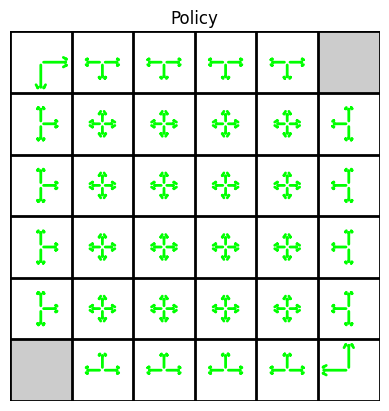

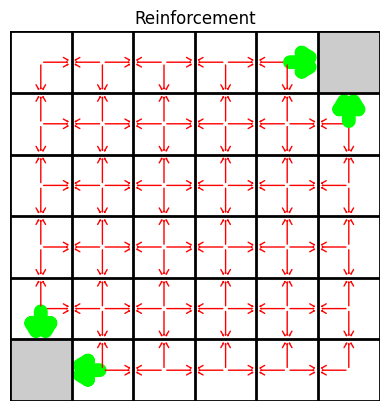

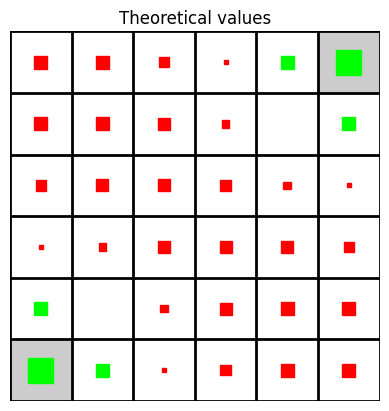

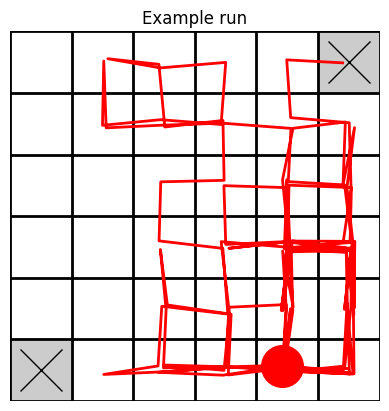

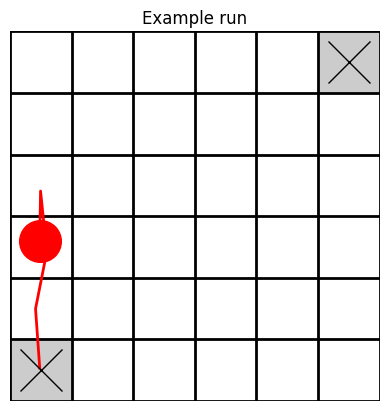

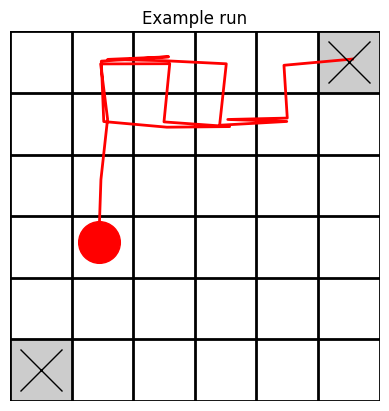

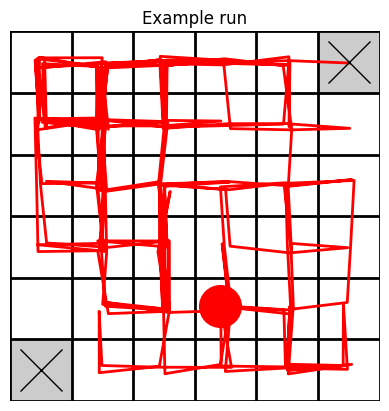

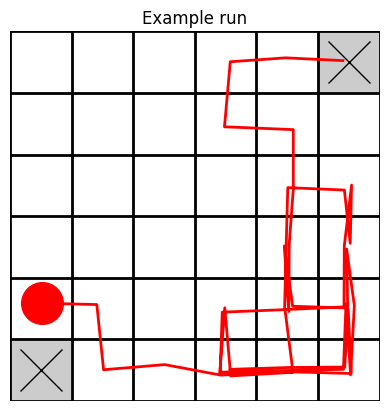

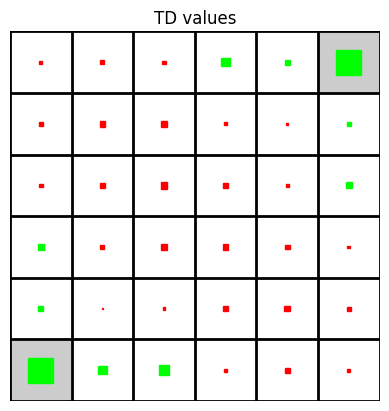

In [ ]:
# @title TD learning with random policy {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def gridworld_with_dumb_policy():
    printflag = True
    NX, NY = 6, 6  # Size of gridworld

    # Initialize value function
    value = np.zeros((NX, NY))
    value[0, 0] = 10  # (1,1) in MATLAB is (0,0) in Python
    value[NX-1, NY-1] = 10

    # Initialize reinforcement and policy
    areward = initialize_reinforcement(NX, NY)
    policy = random_policy(NX, NY)

    # Visualize initial policy
    show_policy(NX, NY, policy)

    # Visualize reinforcement
    show_reinforcement(NX, NY, policy, areward)

    # Visualize initial values
    # show_values(NX, NY, value)

    # Iterative computation of value function
    for k in range(2, 11):
        value = evaluate_policy_step(NX, NY, policy, value, areward)

    # Visualize theoretical values
    show_values(NX, NY, value, 'Theoretical values')

    # Simulate a few runs with random policy
    for k in range(1, 6):
        xinit, yinit = entry_point(NX, NY)
        xt, yt, at, nt = one_grid_run(NX, NY, xinit, yinit, policy)
        show_run(NX, NY, xt, yt, nt)

    # Initialize value function again
    value = np.zeros((NX, NY))
    value[0, 0] = 10  # (1,1) in MATLAB is (0,0) in Python
    value[NX-1, NY-1] = 10

    # discounting of future rewards
    gamma = 0.9

    # learning rate
    alpha = 0.05

    # Simulate many runs with random policy but TD evaluation
    for k in range(1, 50):
        xinit, yinit = entry_point(NX, NY)
        value, xt, yt, at, nt = one_TD_run(NX, NY, xinit, yinit, policy, areward, gamma, alpha, value)

    # Visualize TD values
    show_values(NX, NY, value, 'TD values')


def initialize_reinforcement(NX, NY):
    areward = -np.ones((NX, NY, 4))  # Reward: left, right, down, up
    areward[1, 0, 0] = 10  # Moving into (2,1) left
    areward[0, 1, 2] = 10  # Moving into (1,2) down
    areward[NX-2, NY-1, 1] = 10  # Moving into (NX-1,NY) right
    areward[NX-1, NY-2, 3] = 10  # Moving into (NX,NY-1) up
    return areward

def random_policy(NX, NY):
    policy = np.ones((NX, NY, 4))
    policy[0, :, 0] = 0  # No left at x=1
    policy[NX-1, :, 1] = 0  # No right at x=NX
    policy[:, 0, 2] = 0  # No down at y=1
    policy[:, NY-1, 3] = 0  # No up at y=NY
    for i in range(NX):
        for j in range(NY):
            pp = policy[i, j, :]
            policy[i, j, :] = pp / np.sum(pp) if np.sum(pp) > 0 else pp
    return policy

def entry_point(NX, NY):
    xinit = np.ceil(NX * np.random.rand()).astype(int) - 1
    yinit = np.ceil(NY * np.random.rand()).astype(int) - 1
    return xinit, yinit

def one_grid_run(NX, NY, xinit, yinit, policy):
    nt = 0
    xt = [xinit]
    yt = [yinit]
    at = [0]

    if (xt[nt] == 0 and yt[nt] == 0) or (xt[nt] == NX-1 and yt[nt] == NY-1):
        flag = True
    else:
        flag = False

    while not flag:
        pp = policy[xt[nt], yt[nt], :]
        cp = np.cumsum(pp)
        action = np.where(np.random.rand() < cp)[0][0]
        at[nt] = action

        xt.append(xt[nt])
        yt.append(yt[nt])
        at.append(0)

        if action == 0 and xt[nt] > 0:  # Left
            xt[nt+1] -= 1
        elif action == 1 and xt[nt] < NX-1:  # Right
            xt[nt+1] += 1
        elif action == 2 and yt[nt] > 0:  # Down
            yt[nt+1] -= 1
        elif action == 3 and yt[nt] < NY-1:  # Up
            yt[nt+1] += 1

        nt += 1

        if (xt[nt] == 0 and yt[nt] == 0) or (xt[nt] == NX-1 and yt[nt] == NY-1):
            flag = True

    return np.array(xt), np.array(yt), np.array(at), nt + 1

def one_TD_run(NX, NY, xinit, yinit, policy, areward, gamma, alpha, value):
    nt = 0
    xt = [xinit]
    yt = [yinit]
    at = [0]

    if (xt[nt] == 0 and yt[nt] == 0) or (xt[nt] == NX-1 and yt[nt] == NY-1):
        flag = True
    else:
        flag = False

    while not flag:
        pp = policy[xt[nt], yt[nt], :]
        ov = value[xt[nt], yt[nt]]
        cp = np.cumsum(pp)
        action = np.where(np.random.rand() < cp)[0][0]
        at[nt] = action

        xt.append(xt[nt])
        yt.append(yt[nt])
        at.append(0)

        if action == 0 and xt[nt] > 0:  # Left
            xt[nt+1] -= 1
        elif action == 1 and xt[nt] < NX-1:  # Right
            xt[nt+1] += 1
        elif action == 2 and yt[nt] > 0:  # Down
            yt[nt+1] -= 1
        elif action == 3 and yt[nt] < NY-1:  # Up
            yt[nt+1] += 1

        nt += 1

        nv = value[xt[nt], yt[nt]]
        delta = areward[xt[nt], yt[nt], action] + gamma * nv - ov
        value[xt[nt-1], yt[nt-1]] += alpha * delta

        if (xt[nt] == 0 and yt[nt] == 0) or (xt[nt] == NX-1 and yt[nt] == NY-1):
            flag = True

    return value, np.array(xt), np.array(yt), np.array(at), nt + 1

def improved_policy(NX, NY, value):
    beta = 20
    policy = np.zeros((NX, NY, 4))
    for i in range(NX):
        for j in range(NY):
            if (i == 0 and j == 0) or (i == NX-1 and j == NY-1):
                continue
            av = np.zeros(4)
            if i > 0:  # Left
                av[0] = value[i-1, j] - value[i, j]
            if i < NX-1:  # Right
                av[1] = value[i+1, j] - value[i, j]
            if j > 0:  # Down
                av[2] = value[i, j-1] - value[i, j]
            if j < NY-1:  # Up
                av[3] = value[i, j+1] - value[i, j]
            av = np.exp(beta * av)
            policy[i, j, :] = av / np.sum(av) if np.sum(av) > 0 else av
    return policy

def evaluate_policy_step(NX, NY, policy, oldvalue, areward):
    gamma = 0.9
    newvalue = oldvalue.copy()
    for i in range(NX):
        for j in range(NY):
            if (i == 0 and j == 0) or (i == NX-1 and j == NY-1):
                continue
            av = np.zeros(4)
            if i > 0:  # Left
                av[0] = oldvalue[i-1, j]
            if i < NX-1:  # Right
                av[1] = oldvalue[i+1, j]
            if j > 0:  # Down
                av[2] = oldvalue[i, j-1]
            if j < NY-1:  # Up
                av[3] = oldvalue[i, j+1]
            ar = areward[i, j, :]
            ap = policy[i, j, :]
            newvalue[i, j] = np.sum(ap * (ar + gamma * av))
    return newvalue

def show_values(NX, NY, value, titlestring):
    vmax = np.max(value)
    if vmax > 10:
        value = 8 * value / vmax
        value[0, 0] = 10
        value[NX-1, NY-1] = 10

    plt.figure()
    plt.fill([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'w')
    plt.fill([0, 0, 1, 1, 0], [0, 1, 1, 0, 0], color=[0.8, 0.8, 0.8])
    plt.fill([NX-1, NX-1, NX, NX, NX-1], [NY-1, NY, NY, NY-1, NY-1], color=[0.8, 0.8, 0.8])

    plt.plot([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'k', linewidth=2)
    for i in range(NX-1):
        plt.plot([i+1, i+1], [0, NY], 'k', linewidth=2)
        plt.plot([0, NX], [i+1, i+1], 'k', linewidth=2)

    scale = 0.02
    for i in range(NX):
        for j in range(NY):
            if value[i, j] > 0:
                clr = [0, 1, 0]
            else:
                clr = [1, 0, 0]
            wid = scale * abs(value[i, j])
            plt.fill(i+0.5+wid*np.array([-1, 1, 1, -1]), j+0.5+wid*np.array([-1, -1, 1, 1]), color=clr)

    plt.axis([0, NX, 0, NY])
    plt.gca().set_aspect('equal')
    plt.title(titlestring)
    plt.axis('off')
    plt.show()

def show_policy(NX, NY, policy):
    plt.figure()
    plt.fill([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'w')
    plt.fill([0, 0, 1, 1, 0], [0, 1, 1, 0, 0], color=[0.8, 0.8, 0.8])
    plt.fill([NX-1, NX-1, NX, NX, NX-1], [NY-1, NY, NY, NY-1, NY-1], color=[0.8, 0.8, 0.8])

    plt.plot([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'k', linewidth=2)
    for i in range(NX-1):
        plt.plot([i+1, i+1], [0, NY], 'k', linewidth=2)
        plt.plot([0, NX], [i+1, i+1], 'k', linewidth=2)

    maxp = np.max(policy)
    for i in range(NX):
        for j in range(NY):
            if (i == 0 and j == 0) or (i == NX-1 and j == NY-1):
                continue
            pp = 0.5 * policy[i, j, :] / maxp
            if pp[0] > 0:  # Left
                draw_arrow(i+0.5, i+0.5-pp[0], j+0.5, j+0.5, [0, 1, 0], 2)
            if pp[1] > 0:  # Right
                draw_arrow(i+0.5, i+0.5+pp[1], j+0.5, j+0.5, [0, 1, 0], 2)
            if pp[2] > 0:  # Down
                draw_arrow(i+0.5, i+0.5, j+0.5, j+0.5-pp[2], [0, 1, 0], 2)
            if pp[3] > 0:  # Up
                draw_arrow(i+0.5, i+0.5, j+0.5, j+0.5+pp[3], [0, 1, 0], 2)

    plt.axis([0, NX, 0, NY])
    plt.gca().set_aspect('equal')
    plt.title('Policy')
    plt.axis('off')
    plt.show()

def show_reinforcement(NX, NY, policy, areward):
    plt.figure()
    plt.fill([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'w')
    plt.fill([0, 0, 1, 1, 0], [0, 1, 1, 0, 0], color=[0.8, 0.8, 0.8])
    plt.fill([NX-1, NX-1, NX, NX, NX-1], [NY-1, NY, NY, NY-1, NY-1], color=[0.8, 0.8, 0.8])

    plt.plot([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'k', linewidth=2)
    for i in range(NX-1):
        plt.plot([i+1, i+1], [0, NY], 'k', linewidth=2)
        plt.plot([0, NX], [i+1, i+1], 'k', linewidth=2)

    for i in range(NX):
        for j in range(NY):
            if (i == 0 and j == 0) or (i == NX-1 and j == NY-1):
                continue
            pp = policy[i, j, :]
            if pp[0] > 0:  # Left
                clr = [0, 1, 0] if areward[i, j, 0] > 0 else [1, 0, 0]
                wid = abs(areward[i, j, 0])
                draw_arrow(i+0.5, i, j+0.5, j+0.5, clr, wid)
            if pp[1] > 0:  # Right
                clr = [0, 1, 0] if areward[i, j, 1] > 0 else [1, 0, 0]
                wid = abs(areward[i, j, 1])
                draw_arrow(i+0.5, i+1, j+0.5, j+0.5, clr, wid)
            if pp[2] > 0:  # Down
                clr = [0, 1, 0] if areward[i, j, 2] > 0 else [1, 0, 0]
                wid = abs(areward[i, j, 2])
                draw_arrow(i+0.5, i+0.5, j+0.5, j, clr, wid)
            if pp[3] > 0:  # Up
                clr = [0, 1, 0] if areward[i, j, 3] > 0 else [1, 0, 0]
                wid = abs(areward[i, j, 3])
                draw_arrow(i+0.5, i+0.5, j+0.5, j+1, clr, wid)

    plt.axis([0, NX, 0, NY])
    plt.gca().set_aspect('equal')
    plt.title('Reinforcement')
    plt.axis('off')
    plt.show()

def draw_arrow(xi, xf, yi, yf, clr, wid):
    eps = 0.4
    dx = eps * (xf - xi)
    dy = eps * (yf - yi)
    cosa = np.cos(np.pi/6)
    sina = np.sin(np.pi/6)
    f1x = dx*cosa - dy*sina
    f1y = dx*sina + dy*cosa
    f2x = dx*cosa + dy*sina
    f2y = -dx*sina + dy*cosa

    arrow = FancyArrowPatch((xi, yi), (xf, yf), color=clr, linewidth=wid, arrowstyle='->')
    plt.gca().add_patch(arrow)
    arrow = FancyArrowPatch((xf-f1x, yf-f1y), (xf, yf), color=clr, linewidth=wid, arrowstyle='->')
    plt.gca().add_patch(arrow)
    arrow = FancyArrowPatch((xf-f2x, yf-f2y), (xf, yf), color=clr, linewidth=wid, arrowstyle='->')
    plt.gca().add_patch(arrow)

def show_run(NX, NY, xt, yt, nt):
    plt.figure()
    plt.fill([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'w')
    plt.fill([0, 0, 1, 1, 0], [0, 1, 1, 0, 0], color=[0.8, 0.8, 0.8])
    plt.fill([NX-1, NX-1, NX, NX, NX-1], [NY-1, NY, NY, NY-1, NY-1], color=[0.8, 0.8, 0.8])

    plt.plot([0, 0, NX, NX, 0], [0, NY, NY, 0, 0], 'k', linewidth=2)
    for i in range(NX-1):
        plt.plot([i+1, i+1], [0, NY], 'k', linewidth=2)
        plt.plot([0, NX], [i+1, i+1], 'k', linewidth=2)

    dx = -0.1 + 0.2 * np.random.rand(nt)
    dy = -0.1 + 0.2 * np.random.rand(nt)

    plt.plot(xt + dx + 0.5, yt + dy + 0.5, 'r', linewidth=2)
    plt.plot(xt[0] + dx[0] + 0.5, yt[0] + dy[0] + 0.5, 'ro', markersize=30, linewidth=2)
    plt.plot(0.5, 0.5, 'kx', markersize=30, linewidth=2)
    plt.plot(NX-0.5, NY-0.5, 'kx', markersize=30, linewidth=2)

    plt.axis([0, NX, 0, NY])
    plt.gca().set_aspect('equal')
    plt.title('Example run')
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    gridworld_with_dumb_policy()

# Points to note

<br>

- In TD learning, each action outcome immediately contributes to the value function $V(s)$.

<br>

- Its basis is the temporal prediction error
$$
\delta(a) =   r(s') + \gamma V_\pi(s') - V_\pi(s), \qquad\qquad s \stackrel{a}{\to} s'
$$
where $r(s')$ is the reward received after action $a$ and $\gamma<1$ is a discounting parameter.  

<br>

- The update rule is retrospective (applies to previous state) after each action $a$

$$
V_\pi(s) \rightarrow V_\pi(s) + \alpha \, \delta(a)
$$

where $\alpha<<1$ is a learning rate.

<br>

- The value function  $V_\pi(s)$ provides a succinct summary of the reinforcement structure $r(a,s)$.


# TD learning summary

<br>

- Agent estimates **total expected reward**, from stimulus to end of trial (episodic), or from current position to exit (continuous).

<br>

- Prediction error sums **rewards** and  **change in expectations**.

$$
\delta(\tau)  = r(\tau,s) + \Delta v(\tau,s)
$$

<br>

- Bases estimates on earlier estimates (bootstrapping).

<br>


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec10_episodic_and_continuous.png" width="800">

# **Next:**

# $\qquad\qquad$ **Policy learning**